#PIP Installations

In [ ]:
!pip install --upgrade --no-cache-dir numpy>=2.0.0
!pip install --upgrade --no-cache-dir --force-reinstall gensim scikit-learn nltk pyLDAvis wordcloud spacy
!python -m spacy download en_core_web_sm

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.3 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.3 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.3.3 which is incompatible.
cupy-cuda12x 13.3.0 requires numpy<2.3,>=1.22, but you have numpy 2.3.3 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.3.3 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.3 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 254.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 350.9 MB/s eta 0:00:

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 125.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
!pip install transformers sentencepiece


In [ ]:
!pip install transformers datasets torch matplotlib scikit-learn


#Import libraries

In [ ]:
#Python libraries
import bz2
import re
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

# NLP / ML
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss, accuracy_score

import gensim
from gensim import corpora, models
from gensim.models.coherencemodel import CoherenceModel
from gensim.models import CoherenceModel, LdaModel

# Visualization
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns

# Download NLTK resources
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
import torch
from torch.utils.data import DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm

import transformers

from sklearn.svm import LinearSVC


from sklearn.linear_model import SGDClassifier

#Load Training Data

In [ ]:
DATA_PATH = "train.ft.txt.bz2"
SAMPLE_ROWS = 100000

def read_bz2_lines(path, max_rows=None):
    rows = []
    with bz2.open(path, "rt") as f:
        for i, line in enumerate(f):
            if max_rows and i >= max_rows:
                break
            rows.append(line.rstrip("\n"))
    return rows

print("Loading...")
rows = read_bz2_lines(DATA_PATH, max_rows=SAMPLE_ROWS)
print("Loaded rows:", len(rows))

# Build DataFrame: split label and text
def split_label_text(row):
    parts = row.split(" ", 1)
    label = parts[0].replace("__label__", "") if parts else None
    text = parts[1] if len(parts) > 1 else ""
    return label, text

labels_texts = [split_label_text(r) for r in rows]
df = pd.DataFrame(labels_texts, columns=["label", "review"])
df["label"] = df["label"].astype(int)
df.head()


Loading...
Loaded rows: 100000


,label,review
0,2,Stuning even for the non-gamer: This sound tra...
1,2,The best soundtrack ever to anything.: I'm rea...
2,2,Amazing!: This soundtrack is my favorite music...
3,2,Excellent Soundtrack: I truly like this soundt...
4,2,"Remember, Pull Your Jaw Off The Floor After He..."


In [ ]:
df['label'].value_counts()

,count
label,
2,51267
1,48733


In [ ]:
df.groupby('label').head(5)
print("Positive Reviews (label = 2):")
print(df[df['label'] == 2].head(5)[['label', 'review']])

print("\nNegative Reviews (label = 1):")
print(df[df['label'] == 1].head(5)[['label', 'review']])
df.groupby('label').apply(lambda x: x.sample(5, random_state=42))[['label', 'review']]


NameError: name 'df' is not defined

#PreProcessing

In [ ]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_simple(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)  # remove URLs
    text = re.sub(r"[^a-z\s]", " ", text)  # keep only letters and spaces
    tokens = [w for w in text.split() if w not in stop_words and len(w) > 2]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return " ".join(tokens)

# Apply (use tqdm for progress)
tqdm.pandas()
df["cleaned"] = df["review"].progress_apply(preprocess_simple)

# Quick check
df[["review","cleaned"]].head(6)


100%|██████████| 100000/100000 [00:22<00:00, 4410.70it/s]


,review,cleaned
0,Stuning even for the non-gamer: This sound tra...,stuning even non gamer sound track beautiful p...
1,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything reading lot revi...
2,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hand in...
3,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing played game kn...
5,an absolute masterpiece: I am quite sure any o...,absolute masterpiece quite sure actually takin...


In [ ]:
os.makedirs("outputs", exist_ok=True)
df.to_csv("outputs/cleaned_reviews_sample.csv", index=False)
print("Saved cleaned data to outputs/cleaned_reviews_sample.csv")


Saved cleaned data to outputs/cleaned_reviews_sample.csv


In [ ]:
df.to_csv("/content/drive/MyDrive/cleaned_reviews_sample.csv", index=False)
print("Saved to Google Drive: MyDrive/cleaned_reviews_sample.csv")


Saved to Google Drive: MyDrive/cleaned_reviews_sample.csv


In [ ]:
import pandas as pd

# Load the cleaned dataset
df = pd.read_csv("outputs/cleaned_reviews_sample.csv")

# Get number of rows and columns
print("Dataset shape (rows, columns):", df.shape)

# Display column names
print("\nColumns in dataset:")
print(df.columns.tolist())

# Preview first few rows
print("\nSample rows:")
print(df.head())

# Overview of data types and missing values
print("\nDataset info:")
print(df.info())

# Summary statistics (useful if numeric columns exist)
print("\nSummary statistics:")
print(df.describe(include='all').transpose())


Dataset shape (rows, columns): (100000, 3)

Columns in dataset:
['label', 'review', 'cleaned']

Sample rows:
   label                                             review  \
0      2  Stuning even for the non-gamer: This sound tra...   
1      2  The best soundtrack ever to anything.: I'm rea...   
2      2  Amazing!: This soundtrack is my favorite music...   
3      2  Excellent Soundtrack: I truly like this soundt...   
4      2  Remember, Pull Your Jaw Off The Floor After He...   

                                             cleaned  
0  stuning even non gamer sound track beautiful p...  
1  best soundtrack ever anything reading lot revi...  
2  amazing soundtrack favorite music time hand in...  
3  excellent soundtrack truly like soundtrack enj...  
4  remember pull jaw floor hearing played game kn...  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   ------

#Data Visualizations

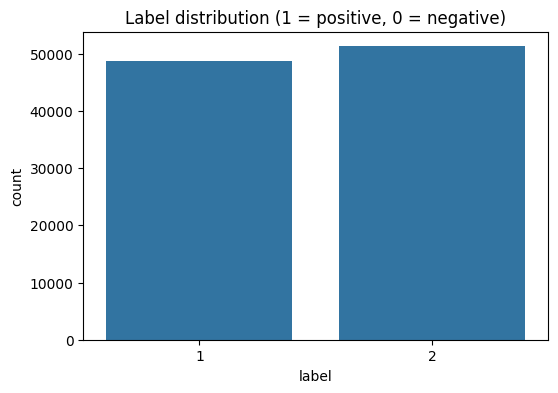

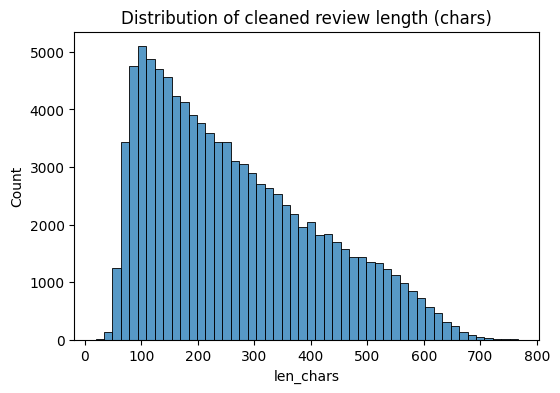

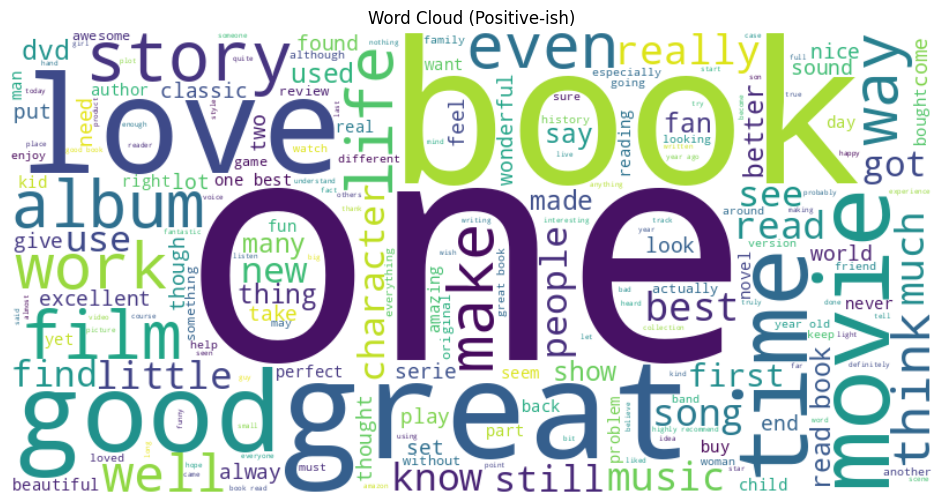

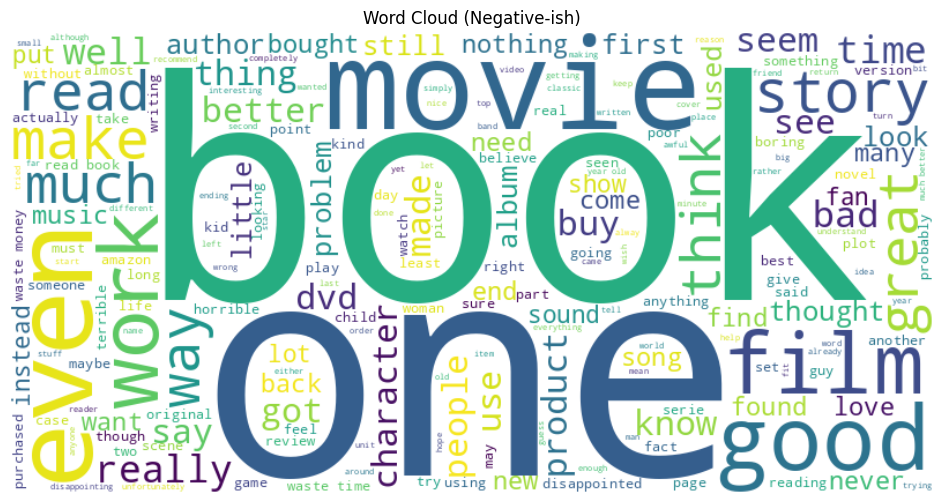

In [ ]:
# Label distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df["label"])
plt.title("Label distribution (1 = positive, 0 = negative)")
plt.show()

# Review length (characters or tokens)
df["len_chars"] = df["cleaned"].astype(str).apply(len)
plt.figure(figsize=(6,4))
sns.histplot(df["len_chars"], bins=50, kde=False)
plt.title("Distribution of cleaned review length (chars)")
plt.show()

# Word cloud for positive and negative
pos_text = " ".join(df[df["label"]==2]["cleaned"].dropna().astype(str)) if 2 in df["label"].unique() else " ".join(df[df["label"]==1]["cleaned"].dropna().astype(str))
neg_text = " ".join(df[df["label"]==1]["cleaned"].dropna().astype(str)) if 1 in df["label"].unique() else " ".join(df[df["label"]==0]["cleaned"].dropna().astype(str))

wc = WordCloud(width=800, height=400, background_color="white")
plt.figure(figsize=(14,6))
plt.imshow(wc.generate(pos_text), interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud (Positive-ish)")
plt.show()

plt.figure(figsize=(14,6))
plt.imshow(wc.generate(neg_text), interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud (Negative-ish)")
plt.show()


#Tokenization

In [ ]:
# Tokenize into lists
texts = [doc.split() for doc in df["cleaned"].astype(str).tolist()]

# Build dictionary and corpus
dictionary = corpora.Dictionary(texts)
# Filter extremes (very rare and very common tokens)
dictionary.filter_extremes(no_below=15, no_above=0.5, keep_n=100000)
corpus = [dictionary.doc2bow(text) for text in texts]

print("Num tokens:", len(dictionary))


Num tokens: 13115


#Topic Modeling LDA

In [ ]:
topic_range = list(range(2, 16))

Topics: 2, Coherence: 0.3670
Topics: 3, Coherence: 0.4492
Topics: 4, Coherence: 0.4409
Topics: 5, Coherence: 0.4991
Topics: 6, Coherence: 0.5010
Topics: 7, Coherence: 0.5078
Topics: 8, Coherence: 0.5225
Topics: 9, Coherence: 0.5330
Topics: 10, Coherence: 0.5294
Topics: 11, Coherence: 0.5293
Topics: 12, Coherence: 0.5466
Topics: 13, Coherence: 0.5461
Topics: 14, Coherence: 0.5707
Topics: 15, Coherence: 0.5254


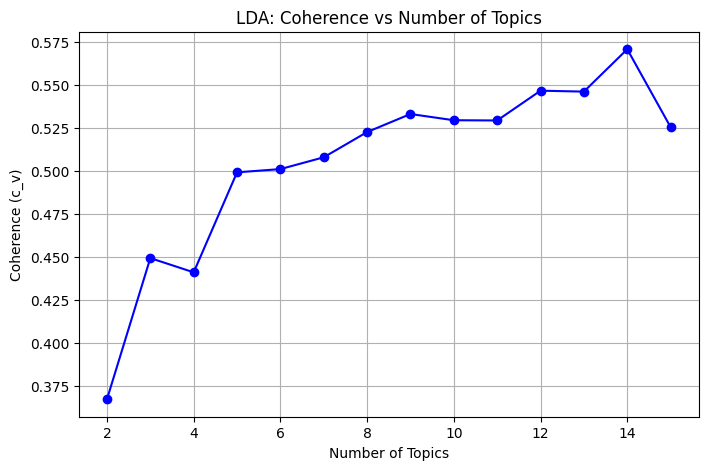

In [ ]:
def compute_coherence(dictionary, corpus, texts, topic_range, passes=10, iterations=50):
    coherence_values = []
    for num_topics in topic_range:
        lda = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=42,
            passes=passes,
            iterations=iterations,
            alpha='auto',
            per_word_topics=True
        )
        cm = CoherenceModel(
            model=lda,
            texts=texts,
            dictionary=dictionary,
            coherence='c_v'
        )
        coh = cm.get_coherence()
        coherence_values.append(coh)
        print(f"Topics: {num_topics}, Coherence: {coh:.4f}")
    return coherence_values

# Usage
topic_range = list(range(2, 16))  # try topics from 2 to 15
coherence_vals = compute_coherence(dictionary, corpus, texts, topic_range)

# Plot
plt.figure(figsize=(8,5))
plt.plot(topic_range, coherence_vals, marker='o', color='blue')
plt.xlabel("Number of Topics")
plt.ylabel("Coherence (c_v)")
plt.title("LDA: Coherence vs Number of Topics")
plt.grid(True)
plt.show()


Topics: 2, Log Perplexity: -7.7011
Topics: 3, Log Perplexity: -7.6400
Topics: 4, Log Perplexity: -7.6377
Topics: 5, Log Perplexity: -7.6565
Topics: 6, Log Perplexity: -7.6727
Topics: 7, Log Perplexity: -7.6859
Topics: 8, Log Perplexity: -7.6968
Topics: 9, Log Perplexity: -7.7398
Topics: 10, Log Perplexity: -7.9165
Topics: 11, Log Perplexity: -8.1743
Topics: 12, Log Perplexity: -8.4324
Topics: 13, Log Perplexity: -8.6214
Topics: 14, Log Perplexity: -8.7227
Topics: 15, Log Perplexity: -8.8145


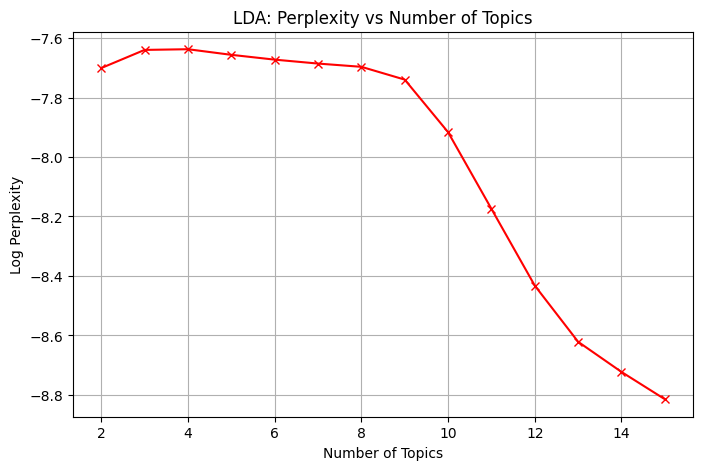

In [ ]:
def compute_perplexity(dictionary, corpus, topic_range, passes=10, iterations=50):
    perp_vals = []
    for num_topics in topic_range:
        lda = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=42,
            passes=passes,
            iterations=iterations,
            alpha='auto',
            per_word_topics=True
        )
        perp = lda.log_perplexity(corpus)
        perp_vals.append(perp)
        print(f"Topics: {num_topics}, Log Perplexity: {perp:.4f}")
    return perp_vals

perplexity_vals = compute_perplexity(dictionary, corpus, topic_range)

plt.figure(figsize=(8,5))
plt.plot(topic_range, perplexity_vals, marker='x', color='red')
plt.xlabel("Number of Topics")
plt.ylabel("Log Perplexity")
plt.title("LDA: Perplexity vs Number of Topics")
plt.grid(True)
plt.show()


In [ ]:
def compute_log_likelihood(dictionary, corpus, topic_range, passes=10, iterations=50):
    ll_vals = []
    for num_topics in topic_range:
        lda = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=42,
            passes=passes,
            iterations=iterations,
            alpha='auto',
            per_word_topics=True
        )
        # gensim provides a “bound” method (variational bound) as approximate log likelihood
        ll = lda.bound(corpus)
        ll_vals.append(ll)
        print(f"Topics: {num_topics}, Log Likelihood (bound): {ll:.4f}")
    return ll_vals

likelihood_vals = compute_log_likelihood(dictionary, corpus, topic_range)




Topics: 2, Log Likelihood (bound): -28885065.9508
Topics: 3, Log Likelihood (bound): -28655924.0967
Topics: 4, Log Likelihood (bound): -28647228.8361
Topics: 5, Log Likelihood (bound): -28717871.2018
Topics: 6, Log Likelihood (bound): -28778571.6213
Topics: 7, Log Likelihood (bound): -28828061.4834
Topics: 8, Log Likelihood (bound): -28869088.7836
Topics: 9, Log Likelihood (bound): -29030484.4032
Topics: 10, Log Likelihood (bound): -29693129.7408
Topics: 11, Log Likelihood (bound): -30660098.6884
Topics: 12, Log Likelihood (bound): -31628263.2164
Topics: 13, Log Likelihood (bound): -32336962.4653
Topics: 14, Log Likelihood (bound): -32717098.9494
Topics: 15, Log Likelihood (bound): -33061222.4660


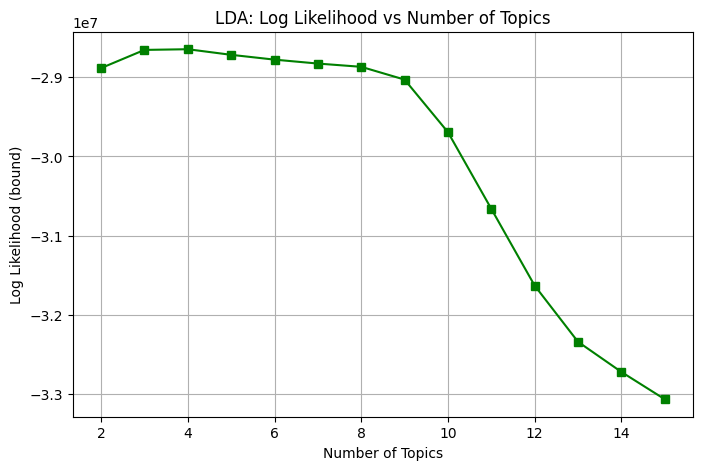

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(topic_range, likelihood_vals, marker='s', color='green')
plt.xlabel("Number of Topics")
plt.ylabel("Log Likelihood (bound)")
plt.title("LDA: Log Likelihood vs Number of Topics")
plt.grid(True)
plt.show()

In [ ]:
# Create DataFrame combining all metrics
df_metrics = pd.DataFrame({
    "num_topics": topic_range,
    "coherence": coherence_vals,
    "perplexity": perplexity_vals,
    "log_likelihood": likelihood_vals
})

print(df_metrics)

# Let’s pick the topic number with highest coherence as one candidate
best_by_coh = df_metrics.loc[df_metrics['coherence'].idxmax(), 'num_topics']
print("Best by Coherence:", best_by_coh)

# And pick topic number where perplexity is “least negative” (highest)
best_by_perp = df_metrics.loc[df_metrics['perplexity'].idxmax(), 'num_topics']
print("Best by Perplexity:", best_by_perp)

# And pick topic number where log likelihood is maximized
best_by_ll = df_metrics.loc[df_metrics['log_likelihood'].idxmax(), 'num_topics']
print("Best by Log Likelihood:", best_by_ll)


In [ ]:
# Function to train LDA and display topics
def train_lda(corpus, dictionary, num_topics=8, passes=10, random_state=42):
    lda_model = gensim.models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=random_state,
        update_every=1,
        chunksize=1000,
        passes=passes,
        alpha='auto',
        per_word_topics=True
    )
    return lda_model

# Train model (choose num_topics based on experimentation)
NUM_TOPICS = 14
lda_model = train_lda(corpus, dictionary, num_topics=NUM_TOPICS, passes=10)

# Print top words per topic
for idx, topic in lda_model.print_topics(-1):
    print("Topic: {} \nWords: {}".format(idx, topic))
    print()


Topic: 0 
Words: 0.044*"camera" + 0.039*"drive" + 0.026*"computer" + 0.021*"sony" + 0.020*"system" + 0.018*"bag" + 0.017*"setting" + 0.017*"print" + 0.015*"device" + 0.013*"speaker"

Topic: 1 
Words: 0.078*"game" + 0.062*"play" + 0.051*"fun" + 0.045*"kid" + 0.028*"toy" + 0.025*"dog" + 0.021*"tape" + 0.020*"break" + 0.016*"graphic" + 0.014*"control"

Topic: 2 
Words: 0.037*"work" + 0.029*"buy" + 0.024*"bought" + 0.020*"back" + 0.019*"money" + 0.019*"year" + 0.018*"got" + 0.018*"day" + 0.014*"problem" + 0.013*"would"

Topic: 3 
Words: 0.042*"ear" + 0.038*"window" + 0.032*"disk" + 0.030*"blade" + 0.028*"stone" + 0.024*"heat" + 0.022*"roll" + 0.022*"sold" + 0.021*"luck" + 0.021*"driver"

Topic: 4 
Words: 0.145*"movie" + 0.053*"film" + 0.030*"bad" + 0.029*"watch" + 0.021*"worst" + 0.020*"seen" + 0.019*"funny" + 0.018*"scene" + 0.015*"see" + 0.015*"saw"

Topic: 5 
Words: 0.030*"use" + 0.021*"product" + 0.018*"quality" + 0.016*"easy" + 0.016*"nice" + 0.015*"price" + 0.013*"set" + 0.013*"great

In [ ]:
# Coherence
coherence_model_lda = CoherenceModel(model=lda_model, texts=texts, dictionary=dictionary, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print("LDA Coherence Score:", coherence_lda)


LDA Coherence Score: 0.5431681218768569


In [ ]:
# Perplexity
print("LDA Perplexity:", lda_model.log_perplexity(corpus))

LDA Perplexity: -9.436665792976918


In [ ]:
import joblib

# lda_model is the trained model
joblib.dump(lda_model, "lda_model.pkl")
print("LDA model saved successfully")


LDA model saved successfully


#Sentiment Analysis

#**Logistic Regression**

In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# # Create a binary label column (assuming 1 is negative and 2 is positive based on previous output)
# df["label_bin"] = df["label"].apply(lambda x: 1 if x == 2 else 0)

# X = df["cleaned"].astype(str)
# y = df["label_bin"]

# # Train/test split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# tfidf_vectorizer_sent = TfidfVectorizer(max_features=20000, ngram_range=(1,2), stop_words='english')
# X_train_tfidf = tfidf_vectorizer_sent.fit_transform(X_train)
# X_test_tfidf = tfidf_vectorizer_sent.transform(X_test)

# # Train Logistic Regression
# clf = LogisticRegression(max_iter=1000)
# clf.fit(X_train_tfidf, y_train)

# # Evaluate
# y_pred = clf.predict(X_test_tfidf)
# print("Accuracy:", accuracy_score(y_test, y_pred))
# print(classification_report(y_test, y_pred))

Accuracy: 0.88375
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      9747
           1       0.88      0.90      0.89     10253

    accuracy                           0.88     20000
   macro avg       0.88      0.88      0.88     20000
weighted avg       0.88      0.88      0.88     20000



Accuracy: 0.8648
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      9747
           1       0.86      0.87      0.87     10253

    accuracy                           0.86     20000
   macro avg       0.86      0.86      0.86     20000
weighted avg       0.86      0.86      0.86     20000



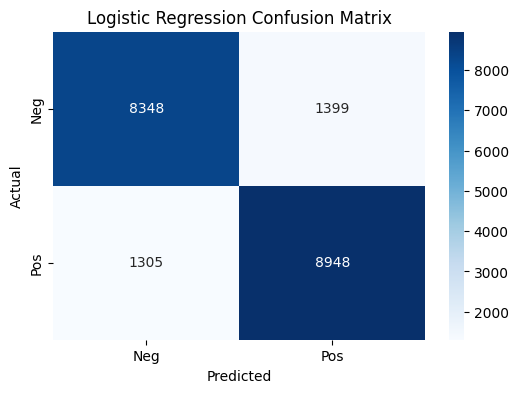

In [ ]:
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Predictions
# y_pred = clf.predict(X_test_tfidf)

# # Accuracy
# print("Accuracy:", accuracy_score(y_test, y_pred))

# # Classification Report
# print(classification_report(y_test, y_pred))

# # Confusion Matrix
# cm = confusion_matrix(y_test, y_pred)

# # Heatmap
# plt.figure(figsize=(6,4))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Neg","Pos"], yticklabels=["Neg","Pos"])
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("Logistic Regression Confusion Matrix")
# plt.show()

In [ ]:
# import joblib
# joblib.dump(clf, "outputs/sentiment_model.joblib")
# joblib.dump(tfidf_vectorizer_sent, "outputs/sentiment_tfidf_vectorizer.joblib")


['outputs/sentiment_tfidf_vectorizer.joblib']

In [ ]:
X = df["cleaned"].astype(str)
y = df["label_bin"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1,2), stop_words='english')
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)


In [ ]:
# Initialize SGDClassifier for Logistic Regression
n_epochs = 20
batch_size = 5000

log_reg_sgd = SGDClassifier(loss='log_loss', learning_rate='constant',
                            eta0=0.01, max_iter=1, warm_start=True)

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(n_epochs):
    indices = np.random.permutation(X_train_tfidf.shape[0])
    X_train_shuffled = X_train_tfidf[indices]
    y_train_shuffled = np.array(y_train)[indices]

    # Mini-batch training
    for i in range(0, len(y_train_shuffled), batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]
        y_batch = y_train_shuffled[i:i+batch_size]
        log_reg_sgd.partial_fit(X_batch, y_batch, classes=np.unique(y_train))

    # Training loss & accuracy
    y_pred_proba_train = log_reg_sgd.predict_proba(X_train_tfidf)
    y_pred_train = log_reg_sgd.predict(X_train_tfidf)
    train_loss = log_loss(y_train, y_pred_proba_train)
    train_acc = accuracy_score(y_train, y_pred_train)

    # Validation loss & accuracy
    y_pred_proba_val = log_reg_sgd.predict_proba(X_test_tfidf)
    y_pred_val = log_reg_sgd.predict(X_test_tfidf)
    val_loss = log_loss(y_test, y_pred_proba_val)
    val_acc = accuracy_score(y_test, y_pred_val)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{n_epochs} - "
          f"Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f} - "
          f"Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}")


Epoch 1/20 - Train Loss: 0.5739 - Val Loss: 0.5757 - Train Acc: 0.8332 - Val Acc: 0.8240
Epoch 2/20 - Train Loss: 0.5155 - Val Loss: 0.5186 - Train Acc: 0.8426 - Val Acc: 0.8339
Epoch 3/20 - Train Loss: 0.4812 - Val Loss: 0.4851 - Train Acc: 0.8487 - Val Acc: 0.8399
Epoch 4/20 - Train Loss: 0.4587 - Val Loss: 0.4633 - Train Acc: 0.8531 - Val Acc: 0.8437
Epoch 5/20 - Train Loss: 0.4428 - Val Loss: 0.4480 - Train Acc: 0.8569 - Val Acc: 0.8471
Epoch 6/20 - Train Loss: 0.4311 - Val Loss: 0.4368 - Train Acc: 0.8601 - Val Acc: 0.8501
Epoch 7/20 - Train Loss: 0.4222 - Val Loss: 0.4284 - Train Acc: 0.8625 - Val Acc: 0.8520
Epoch 8/20 - Train Loss: 0.4152 - Val Loss: 0.4218 - Train Acc: 0.8648 - Val Acc: 0.8537
Epoch 9/20 - Train Loss: 0.4096 - Val Loss: 0.4166 - Train Acc: 0.8660 - Val Acc: 0.8555
Epoch 10/20 - Train Loss: 0.4051 - Val Loss: 0.4124 - Train Acc: 0.8675 - Val Acc: 0.8564
Epoch 11/20 - Train Loss: 0.4014 - Val Loss: 0.4090 - Train Acc: 0.8686 - Val Acc: 0.8570
Epoch 12/20 - Train

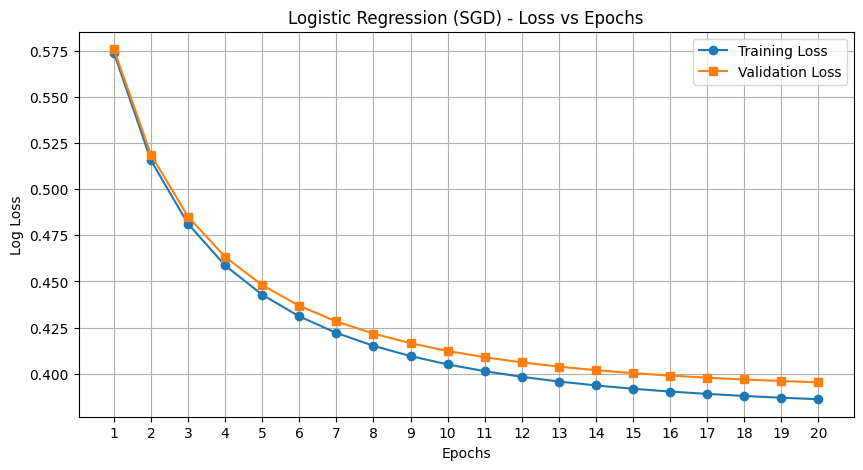

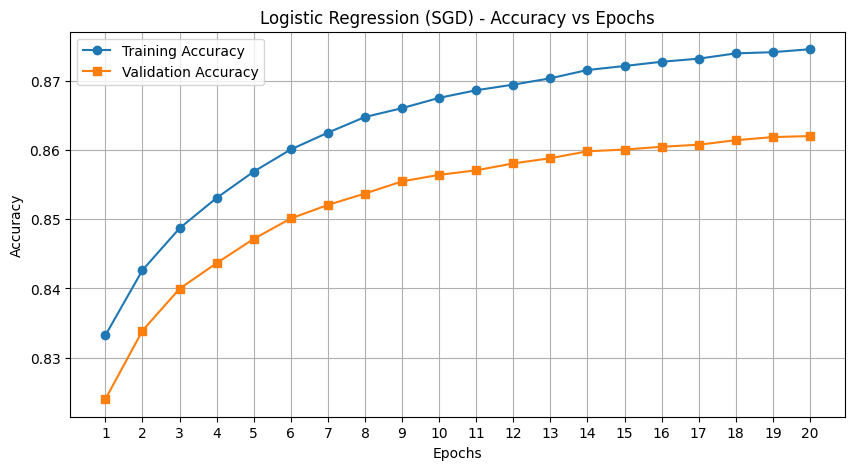

In [ ]:
epochs = range(1, n_epochs + 1)

# Plot 1: Training vs Validation Loss
plt.figure(figsize=(10,5))
plt.plot(epochs, train_losses, marker='o', label='Training Loss')
plt.plot(epochs, val_losses, marker='s', label='Validation Loss')
plt.title("Logistic Regression (SGD) - Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Log Loss")
plt.xticks(epochs)  # ensure integer ticks
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Training vs Validation Accuracy
plt.figure(figsize=(10,5))
plt.plot(epochs, train_accuracies, marker='o', label='Training Accuracy')
plt.plot(epochs, val_accuracies, marker='s', label='Validation Accuracy')
plt.title("Logistic Regression (SGD) - Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.xticks(epochs)
plt.legend()
plt.grid(True)
plt.show()


#**LSTM**

In [ ]:
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/cleaned_reviews_sample.csv")

In [ ]:
df['label'].value_counts()


,count
label,
2,51267
1,48733


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# Convert labels 1/2 → 0/1
df["label_bin"] = df["label"].apply(lambda x: 1 if x == 2 else 0)

X = df["cleaned"].astype(str).values
y = df["label_bin"].values

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Tokenize
tokenizer = Tokenizer(num_words=20000)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad
max_len = 150
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

vocab_size = 20000
embedding_dim = 128

model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_len),
    LSTM(128, return_sequences=False, dropout=0.3, recurrent_dropout=0.3),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=1e-3),
    metrics=['accuracy']
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 565s 897ms/step - accuracy: 0.7799 - loss: 0.4537 - val_accuracy: 0.8799 - val_loss: 0.2909
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 559s 893ms/step - accuracy: 0.9042 - loss: 0.2511 - val_accuracy: 0.8806 - val_loss: 0.3164
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 559s 894ms/step - accuracy: 0.9261 - loss: 0.1981 - val_accuracy: 0.8759 - val_loss: 0.3081
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 555s 889ms/step - accuracy: 0.9391 - loss: 0.1616 - val_accuracy: 0.8784 - val_loss: 0.3462
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 573s 917ms/step - accuracy: 0.9502 - loss: 0.1310 - val_accuracy: 0.8743 - val_loss: 0.3829


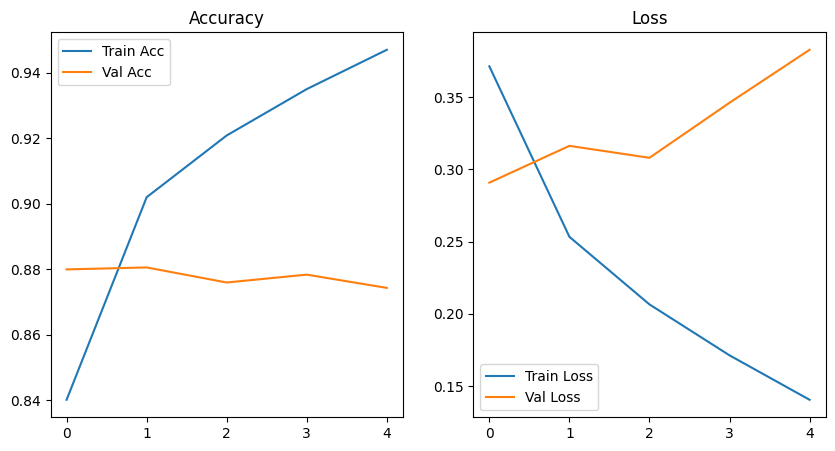

In [ ]:
import matplotlib.pyplot as plt

history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=5,
    batch_size=128,
    verbose=1
)

# Plot accuracy & loss
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title("Loss")
plt.show()


In [ ]:
model.save("lstm_model.h5")
print("LSTM model saved successfully")


LSTM model saved successfully


#**BERT**

In [ ]:
print("Transformers version:", transformers.__version__)
print("Torch version:", torch.__version__)

Transformers version: 4.57.0
Torch version: 2.8.0+cu126


In [ ]:
# Load the cleaned dataset
df = pd.read_csv("/content/drive/MyDrive/cleaned_reviews_sample.csv")

# Create binary labels (1 = positive, 0 = negative)
df["label_bin"] = df["label"].apply(lambda x: 1 if x == 2 else 0)


X = df['cleaned'].astype(str).tolist()
y = df['label_bin'].tolist()

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize(batch):
    return tokenizer(
        batch,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

train_encodings = tokenize(list(X_train))
test_encodings = tokenize(list(X_test))

Training samples: 80000
Testing samples: 20000


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [ ]:
class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = ReviewDataset(train_encodings, y_train)
test_dataset = ReviewDataset(test_encodings, y_test)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
model.to(device)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

optimizer = AdamW(model.parameters(), lr=2e-5)
epochs = 2
total_steps = len(train_loader) * epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=0, num_training_steps=total_steps
)


In [ ]:
train_losses = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for batch in loop:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    preds, true_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(true_labels, preds)
    val_accuracies.append(acc)

    print(f"\nEpoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Validation Accuracy = {acc:.4f}")


Epoch 1/2: 100%|██████████| 5000/5000 [29:04<00:00,  2.87it/s, loss=0.0919]



Epoch 1: Train Loss = 0.2641, Validation Accuracy = 0.9104


Epoch 2/2: 100%|██████████| 5000/5000 [29:03<00:00,  2.87it/s, loss=0.0187]



Epoch 2: Train Loss = 0.1467, Validation Accuracy = 0.9169


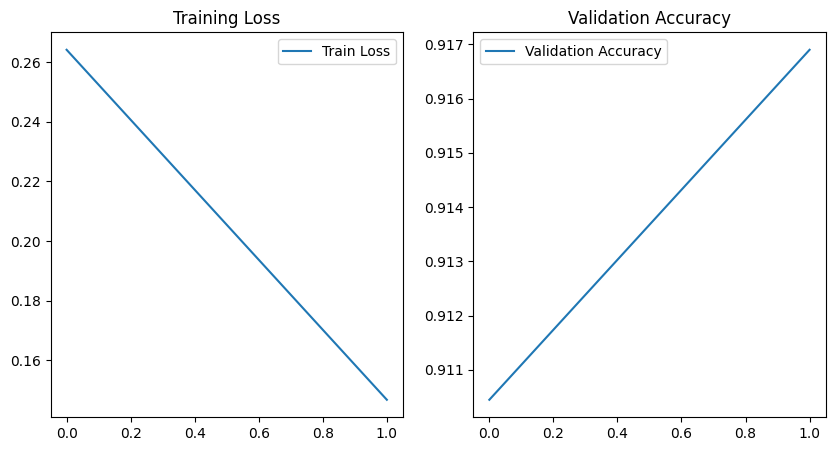

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.legend(); plt.title("Training Loss")

plt.subplot(1,2,2)
plt.plot(val_accuracies, label='Validation Accuracy')
plt.legend(); plt.title("Validation Accuracy")
plt.show()


In [ ]:
y_pred, y_true = [], []
model.eval()
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        y_pred.extend(torch.argmax(logits, dim=1).cpu().numpy())
        y_true.extend(labels.cpu().numpy())

print("Classification Report:\n", classification_report(y_true, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.92      0.91      9602
           1       0.93      0.91      0.92     10398

    accuracy                           0.92     20000
   macro avg       0.92      0.92      0.92     20000
weighted avg       0.92      0.92      0.92     20000

Confusion Matrix:
 [[8848  754]
 [ 908 9490]]


In [ ]:
model.save_pretrained("outputs/bert_sentiment_model")
tokenizer.save_pretrained("outputs/bert_sentiment_model")
print("Model and tokenizer saved successfully!")


Model and tokenizer saved successfully!


In [ ]:
model.save_pretrained("/content/drive/MyDrive/bert_sentiment_model")
tokenizer.save_pretrained("/content/drive/MyDrive/bert_sentiment_model")

('/content/drive/MyDrive/bert_sentiment_model/tokenizer_config.json',
 '/content/drive/MyDrive/bert_sentiment_model/special_tokens_map.json',
 '/content/drive/MyDrive/bert_sentiment_model/vocab.txt',
 '/content/drive/MyDrive/bert_sentiment_model/added_tokens.json')

#**SVM**

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [ ]:
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)


LinearSVC()

In [ ]:
y_pred = svm_model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8802

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.87      0.87      9602
           1       0.88      0.89      0.89     10398

    accuracy                           0.88     20000
   macro avg       0.88      0.88      0.88     20000
weighted avg       0.88      0.88      0.88     20000


Confusion Matrix:
 [[8364 1238]
 [1158 9240]]


In [ ]:
import joblib

joblib.dump(svm_model, "outputs/svm_model.pkl")
joblib.dump(vectorizer, "outputs/tfidf_vectorizer.pkl")


['outputs/tfidf_vectorizer.pkl']

In [ ]:
svm_model = joblib.load("outputs/svm_model.pkl")
vectorizer = joblib.load("outputs/tfidf_vectorizer.pkl")


In [ ]:
X = df["cleaned"].astype(str)
y = df["label_bin"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2), stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [ ]:
n_epochs = 30
batch_size = 5000

sgd_svm = SGDClassifier(loss='hinge', learning_rate='constant',eta0=0.01, max_iter=1, warm_start=True)

train_losses = []
val_accuracies = []

for epoch in range(n_epochs):
    # Shuffle indices
    indices = np.random.permutation(X_train_tfidf.shape[0])
    X_train_shuffled = X_train_tfidf[indices]
    y_train_shuffled = np.array(y_train)[indices]

    # Train in mini-batches
    for i in range(0, len(y_train_shuffled), batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]
        y_batch = y_train_shuffled[i:i+batch_size]
        sgd_svm.partial_fit(X_batch, y_batch, classes=np.unique(y_train))

    # Approximate "loss" using hinge loss on training data
    margins = y_train_shuffled * sgd_svm.decision_function(X_train_tfidf)
    loss = np.mean(np.maximum(0, 1 - margins))  # hinge loss
    train_losses.append(loss)

    # Validation accuracy
    y_pred = sgd_svm.predict(X_test_tfidf)
    val_acc = accuracy_score(y_test, y_pred)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{n_epochs} - Loss: {loss:.4f} - Val Acc: {val_acc:.4f}")


Epoch 1/30 - Loss: 0.9853 - Val Acc: 0.8307
Epoch 2/30 - Loss: 1.0196 - Val Acc: 0.8457
Epoch 3/30 - Loss: 1.0334 - Val Acc: 0.8546
Epoch 4/30 - Loss: 1.0444 - Val Acc: 0.8606
Epoch 5/30 - Loss: 1.0486 - Val Acc: 0.8633
Epoch 6/30 - Loss: 1.0490 - Val Acc: 0.8674
Epoch 7/30 - Loss: 1.0622 - Val Acc: 0.8690
Epoch 8/30 - Loss: 1.0590 - Val Acc: 0.8702
Epoch 9/30 - Loss: 1.0589 - Val Acc: 0.8711
Epoch 10/30 - Loss: 1.0631 - Val Acc: 0.8723
Epoch 11/30 - Loss: 1.0689 - Val Acc: 0.8734
Epoch 12/30 - Loss: 1.0744 - Val Acc: 0.8734
Epoch 13/30 - Loss: 1.0664 - Val Acc: 0.8744
Epoch 14/30 - Loss: 1.0675 - Val Acc: 0.8752
Epoch 15/30 - Loss: 1.0674 - Val Acc: 0.8757
Epoch 16/30 - Loss: 1.0665 - Val Acc: 0.8759
Epoch 17/30 - Loss: 1.0622 - Val Acc: 0.8762
Epoch 18/30 - Loss: 1.0691 - Val Acc: 0.8766
Epoch 19/30 - Loss: 1.0723 - Val Acc: 0.8772
Epoch 20/30 - Loss: 1.0663 - Val Acc: 0.8773
Epoch 21/30 - Loss: 1.0631 - Val Acc: 0.8763
Epoch 22/30 - Loss: 1.0650 - Val Acc: 0.8772
Epoch 23/30 - Loss:

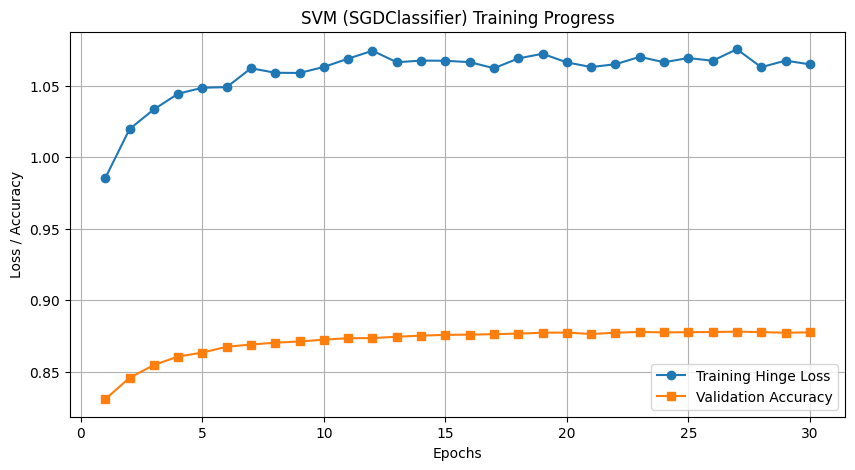

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(range(1, n_epochs+1), train_losses, marker='o', label='Training Hinge Loss')
plt.plot(range(1, n_epochs+1), val_accuracies, marker='s', label='Validation Accuracy')
plt.title("SVM (SGDClassifier) Training Progress")
plt.xlabel("Epochs")
plt.ylabel("Loss / Accuracy")
plt.legend()
plt.grid(True)
plt.show()


#Summarization

In [ ]:
from transformers import pipeline

# Load summarization pipeline (BART is good for reviews)
summarizer = pipeline("summarization", model="facebook/bart-large-cnn")

# Example review
text = df["review"].iloc[0]
print("Original Review:", text)

summary = summarizer(text, max_length=60, min_length=20, do_sample=False)
print("Summary:", summary[0]['summary_text'])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cpu


Original Review: Stuning even for the non-gamer: This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^
Summary: Stuning even for the non-gamer: This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music!


In [ ]:
sample_reviews = df["review"].dropna().sample(5, random_state=42).tolist()

for review in sample_reviews:
    print("\nOriginal:", review[:200], "...")
    summary = summarizer(review, max_length=60, min_length=20, do_sample=False)
    print("Summary:", summary[0]['summary_text'])



Original: I love reading Patricia Cornwell book's: I have read all of Patricia Cornwell's books. I was not happy with Benton dying, but I do like Talley. I hope he will have a bigger part and their relationship ...
Summary: I was not happy with Benton dying, but I do like Talley. I hope he will have a bigger part and their relationship go further. I could not put the book down until I finished reading it. I loved it.

Original: Great African Sampler: Lively and danceable, fun African music: Soukous (Zaire/Ivory Coast), Juju (Nigeria), Highlife (Ghana). Some tunes are longer jams.But look for the Sterns pressing that includes ...
Summary: Soukous (Zaire/Ivory Coast), Juju (Nigeria), Highlife (Ghana) Some tunes are longer jams. Sterns pressing includes two extra tracks.

Original: Great Foot Cream: Recently purchased a jar of this from a shoe store and had seen such a great difference in the softness of my heals. It's not greasy either, which is a plus! Use it twice a day (when ...


Your max_length is set to 60, but your input_length is only 55. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=27)


Summary: Great Foot Cream: Recently purchased a jar of this from a shoe store and had seen such a great difference in the softness of my heals. It's not greasy either, which is a plus! Use it twice a day (when I remember) and recommend it to anyone with

Original: Interesting and informative: This is a great dvd for the Def Leppard fan. I loved the details about the making of Hysteria. You really get a feel for the attention to detail that went into its creatio ...
Summary: This is a great dvd for the Def Leppard fan. I loved the details about the making of Hysteria. Well worth it.

Original: Extremely well written: I thought Carrie was both an awesome movie and an awesome book. I loved the way the book was written, the reports from after the events of the story introducing you into each n ...
Summary: I thought Carrie was both an awesome movie and an awesome book. I wouldn't give this book a full 10, because I didn't think it had enough sub-plots like in the book "IT" and therefore ca

In [ ]:
summarizer.model.save_pretrained("bert_summary_model")
summarizer.tokenizer.save_pretrained("bert_summary_model")

print("BERT summarizer model saved successfully")


/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:3922: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 142, 'min_length': 56, 'early_stopping': True, 'num_beams': 4, 'length_penalty': 2.0, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


BERT summarizer model saved successfully


In [ ]:
from google.colab import files
# files.download("lda_model.pkl")
# files.download("lstm_model.h5")
!zip -r bert_summary_model.zip bert_summary_model
files.download("bert_summary_model.zip")


  adding: bert_summary_model/ (stored 0%)
  adding: bert_summary_model/special_tokens_map.json (deflated 52%)
  adding: bert_summary_model/generation_config.json (deflated 47%)
  adding: bert_summary_model/config.json (deflated 62%)
  adding: bert_summary_model/model.safetensors (deflated 41%)
  adding: bert_summary_model/tokenizer_config.json (deflated 75%)
  adding: bert_summary_model/tokenizer.json (deflated 82%)
  adding: bert_summary_model/vocab.json (deflated 59%)
  adding: bert_summary_model/merges.txt (deflated 53%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>